In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep as mh
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
fpaths = glob.glob("AnalysisZipFramework/submission/analysis_output-lateTracks/*.root")
print(f"found {len(fpaths)} files")

found 482 files


In [3]:
wissals_2022_runs = [8025, 8115, 8120, 8124, 8155, 8157, 8175, 8179, 8182, 8190, 8191, 8248, 8252, 8266, 8269, 8290, 8294, 8301, 8320, 8326, 8327, 8330, 8331, 8332, 8333, 8336, 8728, 8731, 8733, 8736, 8775, 8777, 8798, 8799, 8834, 8841, 8848, 8850, 8906, 8908, 8913, 8915, 8916, 8917, 8930, 8933, 8934, 8943, 8945, 8947, 8948, 8949, 8950, 8970, 8972, 8975, 8977, 8981, 8985, 8987, 9058, 9060, 9069, 9072, 9073, 9092, 9094, 9148, 9166, 9181, 9183, 9188]
wissals_2023_runs = [10604, 10605, 10615, 10694, 10695, 10699, 10700, 10701, 10729, 10732, 10733, 10738, 10775, 10792, 10794, 10796, 10829, 10847, 10849, 10857, 10859, 10881, 10921, 10928, 10955, 10956, 11041, 11070, 11081, 11082, 11086, 11088, 11089, 11093, 11096, 11098, 11127, 11156, 11208, 11211, 11212, 11213, 11243, 11523, 11527, 11528, 11583, 11584, 11585, 11586, 11589, 11590, 11595, 11597, 11613, 11700, 11703]
wissals_2024_noCaloNu_runs = [14743, 14758, 14760, 14767, 14769, 14771, 14777, 14797, 14799, 14804, 14809, 14810, 14906, 14954, 14971, 14972, 14974, 14975, 14977, 14980, 14981, 14985, 15007, 15015, 15016, 15024, 15025, 15031, 15032, 15034, 15050, 15051, 15052, 15055, 15059, 15269, 15270, 15287, 15290, 15387, 15388, 15390, 15391, 15394, 15398, 15415, 15422, 15425, 15429, 15432, 15434, 15438, 15439, 15445, 15446, 15683, 15685, 15687, 15751, 15754, 15755, 15758, 15762, 15763, 15766, 15784, 15785, 15786, 15787, 15789, 15790, 15814, 15818, 15820, 16800, 16929, 16930, 16931, 16934, 16937, 16938, 16940, 16941, 16943, 16974, 17018, 17023, 17095, 17102, 17147, 17199, 17230]
wissals_2024_CaloNu_runs = [15838, 15839, 15844, 15874, 15877, 15878, 15883, 15884, 15903, 15909, 15912, 15913, 15915, 15917, 15918, 15919, 15945, 15946, 15948, 15949, 15951, 15953, 15956, 15957, 15961, 15963, 15967, 15977, 15996, 15998, 16000, 16001, 16018, 16022, 16023, 16028, 16042, 16043, 16057, 16064, 16065, 16068, 16072, 16075, 16076, 16077, 16096, 16098, 16099, 16103, 16393, 16396, 16400, 16403, 16405, 16517, 16531, 16533, 16542, 16558, 16581, 16628, 16635, 16650, 16653, 16658, 16660, 16661, 16663, 16667, 16685, 16696, 16697, 16699, 16715, 16731, 16732, 16798, 16802, 16805, 16848, 16853, 16916, 16923]

good_runs = wissals_2022_runs + wissals_2023_runs + wissals_2024_noCaloNu_runs + wissals_2024_CaloNu_runs

In [4]:
print(f"Total number of good runs: {len(good_runs)}")

Total number of good runs: 305


In [5]:
def get_cutflow_and_yields_for_run_range(files, run_start, run_end, mass=1.1):
    cutflow_dict = {}
    run_yields = {}

    total_lumi = 0
    for fpath in tqdm.tqdm(files):

        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
        if run not in good_runs: continue
        
        if run_start > run or run > run_end:
            continue

        with uproot.open(fpath) as f:
            tree = f["cutflow"]
            lumi = f["meta"].arrays(library="pd")["lumi"][0]
            df = tree.arrays(library="pd")

            run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
            if run not in good_runs: continue

            if run_start <= run <= run_end:

                if len(lumi) != 0: 
                    total_lumi += lumi[0] / 1000 # /pb -> /fb
                
                for idx, row in df.iterrows():
                    cut = row["cut_name"]
                    all = row["all"]
                    passed = row["passed"]
            
                    if cut not in cutflow_dict:
                        cutflow_dict[cut] = {"all": 0, "passed": 0}
            
                    cutflow_dict[cut]["all"] += all
                    cutflow_dict[cut]["passed"] += passed
                    cutflow_dict[cut]["efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[cut]["all"] if cutflow_dict[cut]["all"] > 0 else 0
                    cutflow_dict[cut]["cumulative_efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[list(cutflow_dict.keys())[0]]["all"] if cutflow_dict[list(cutflow_dict.keys())[0]]["all"] > 0 else 0
                    cutflow_dict[cut]["efficiency_error"] = np.sqrt(cutflow_dict[cut]["efficiency"] * (1 - cutflow_dict[cut]["efficiency"]) / cutflow_dict[cut]["all"]) if cutflow_dict[cut]["all"] > 0 else 0


                final_yield = np.amin(df["passed"])
                run_yields[int(run)] = final_yield
                
    cutflow = pd.DataFrame.from_dict(cutflow_dict, orient="index")
    cutflow["rate [events/fb/tonne]"] = cutflow["passed"] / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow = cutflow.sort_values(by='passed', ascending=False)
            
    return cutflow, run_yields

In [6]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]
runs_2024 = [14743, 17230]
runs_all = [8025, 17230]

In [7]:
cutflow_F222, yields_F222 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F222)
cutflow_F223, yields_F223 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F223)
cutflow_F231, yields_F231 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F231)
cutflow_F232, yields_F232 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F232)
cutflow_F241, yields_F241 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F241)
cutflow_tungsten, yields_tungsten = get_cutflow_and_yields_for_run_range(fpaths, *runs_tungsten)
cutflow_F242, yields_F242 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F242)
cutflow_caloNu, yields_caloNu = get_cutflow_and_yields_for_run_range(fpaths, *runs_caloNu, mass=0.68)
cutflow_F243, yields_F243 = get_cutflow_and_yields_for_run_range(fpaths, *runs_F243)

cutflow_2022, yields_2022 = get_cutflow_and_yields_for_run_range(fpaths, *runs_2022)
cutflow_2023, yields_2023 = get_cutflow_and_yields_for_run_range(fpaths, *runs_2023)
cutflow_2024, yields_2024 = get_cutflow_and_yields_for_run_range(fpaths, *runs_2024)
cutflow_all, yields_all = get_cutflow_and_yields_for_run_range(fpaths, *runs_all)

100%|██████████| 482/482 [00:03<00:00, 124.63it/s]


In [8]:
print("Cutflow for F222:")
display(cutflow_F222)
print("\n")
print("Cutflow for F223:")
display(cutflow_F223)
print("\n")
print("Cutflow for F231:")
display(cutflow_F231)
print("\n")
print("Cutflow for F232:")
display(cutflow_F232)
print("\n")
print("Cutflow for F241:")
display(cutflow_F241)
print("\n")
print("Cutflow for Tungsten:")
display(cutflow_tungsten)
print("\n")
print("Cutflow for F242:")
display(cutflow_F242)
print("\n")
print("Cutflow for CaloNu:")
display(cutflow_caloNu)
print("\n")
print("Cutflow for F243:")
display(cutflow_F243)

Cutflow for F222:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,188217,67903,0.360770,0.360770,0.001107,44513.700814
Trigger,67903,57021,0.839742,0.302954,0.001408,37380.023476
Good times,57021,57016,0.999912,0.302927,0.000039,37376.745734
Excluded times,57016,56895,0.997878,0.302284,0.000193,37297.424382
At least one long track,56895,56895,1.000000,0.302284,0.000000,37297.424382
Sanity cut to remove events with missing aux data,56895,56895,1.000000,0.302284,0.000000,37297.424382
VetoNu0 reduced charge < 30 pC,56895,197,0.003463,0.001047,0.000246,129.143028
VetoNu1 reduced charge < 30 pC,197,186,0.944162,0.000988,0.016359,121.931996
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),186,74,0.397849,0.000393,0.035889,48.510579
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),74,74,1.000000,0.000393,0.000000,48.510579




Cutflow for F223:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,90046,46154,0.512560,0.512560,0.001666,31497.487853
Trigger,46154,36830,0.797981,0.409013,0.001869,25134.386567
Good times,36830,36829,0.999973,0.409002,0.000027,25133.704124
Excluded times,36829,36654,0.995248,0.407059,0.000358,25014.276547
At least one long track,36654,36654,1.000000,0.407059,0.000000,25014.276547
Sanity cut to remove events with missing aux data,36654,36654,1.000000,0.407059,0.000000,25014.276547
VetoNu0 reduced charge < 30 pC,36654,194,0.005293,0.002154,0.000379,132.393999
VetoNu1 reduced charge < 30 pC,194,178,0.917526,0.001977,0.019750,121.474907
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),178,105,0.589888,0.001166,0.036866,71.656546
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),105,105,1.000000,0.001166,0.000000,71.656546




Cutflow for F231:


...

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,449068,37434,0.083359,0.083359,0.000412,8834.283117
Trigger,37434,23289,0.622135,0.051861,0.002506,5496.116352
Good times,23289,23289,1.000000,0.051861,0.000000,5496.116352
Excluded times,23289,23142,0.993688,0.051533,0.000519,5461.424905
At least one long track,23142,23142,1.000000,0.051533,0.000000,5461.424905
Sanity cut to remove events with missing aux data,23142,23142,1.000000,0.051533,0.000000,5461.424905
VetoNu0 reduced charge < 30 pC,23142,506,0.021865,0.001127,0.000961,119.414096
VetoNu1 reduced charge < 30 pC,506,478,0.944664,0.001064,0.010164,112.806201
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),478,137,0.286611,0.000305,0.020682,32.331484
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),137,137,1.000000,0.000305,0.000000,32.331484




Cutflow for CaloNu:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,2393188,164545,0.068756,0.068756,0.000164,8845.508327
Trigger,164545,151644,0.921596,0.063365,0.000663,8151.984349
Good times,151644,151641,0.999980,0.063364,0.000011,8151.823077
Excluded times,151641,151604,0.999756,0.063348,0.000040,8149.834054
At least one long track,151604,151604,1.000000,0.063348,0.000000,8149.834054
Sanity cut to remove events with missing aux data,151604,151604,1.000000,0.063348,0.000000,8149.834054
VetoNu0 reduced charge < 30 pC,151604,3934,0.025949,0.001644,0.000408,211.481539
VetoNu1 reduced charge < 30 pC,3934,3750,0.953228,0.001567,0.003366,201.590180
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),3750,867,0.231200,0.000362,0.006885,46.607650
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),867,866,0.998847,0.000362,0.001153,46.553892




Cutflow for F243:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,302120,27260,0.090229,0.090229,0.000521,7004.726398
Trigger,27260,17657,0.647726,0.058444,0.002893,4537.140646
Good times,17657,17657,1.000000,0.058444,0.000000,4537.140646
Excluded times,17657,17657,1.000000,0.058444,0.000000,4537.140646
At least one long track,17657,17657,1.000000,0.058444,0.000000,4537.140646
Sanity cut to remove events with missing aux data,17657,17657,1.000000,0.058444,0.000000,4537.140646
VetoNu0 reduced charge < 30 pC,17657,371,0.021011,0.001228,0.001079,95.332116
VetoNu1 reduced charge < 30 pC,371,354,0.954178,0.001172,0.010856,90.963798
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),354,86,0.242938,0.000285,0.022794,22.098550
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),86,86,1.000000,0.000285,0.000000,22.098550


In [9]:
print("Cutflow for 2022:")
display(cutflow_2022)
print("\n")
print("Cutflow for 2023:")
display(cutflow_2023)
print("\n")
print("Cutflow for 2024:")
display(cutflow_2024)
print("\n")
print("Cutflow for all runs:")
display(cutflow_all)

Cutflow for 2022:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,278263,114057,0.409889,0.409889,0.000932,38136.416614
Trigger,114057,93851,0.822843,0.337274,0.001131,31380.282101
Good times,93851,93845,0.999936,0.337253,0.000026,31378.275924
Excluded times,93845,93549,0.996846,0.336189,0.000183,31279.304539
At least one long track,93549,93549,1.000000,0.336189,0.000000,31279.304539
Sanity cut to remove events with missing aux data,93549,93549,1.000000,0.336189,0.000000,31279.304539
VetoNu0 reduced charge < 30 pC,93549,391,0.004180,0.001405,0.000211,130.735850
VetoNu1 reduced charge < 30 pC,391,364,0.930946,0.001308,0.012822,121.708055
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),364,179,0.491758,0.000643,0.026204,59.850939
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),179,179,1.000000,0.000643,0.000000,59.850939




Cutflow for 2023:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,108900,100362,0.921598,0.921598,0.000815,25279.145663
Trigger,100362,83895,0.835924,0.770386,0.001169,21131.443429
Good times,83895,83895,1.000000,0.770386,0.000000,21131.443429
Excluded times,83895,83460,0.994815,0.766391,0.000248,21021.875780
At least one long track,83460,83460,1.000000,0.766391,0.000000,21021.875780
Sanity cut to remove events with missing aux data,83460,83460,1.000000,0.766391,0.000000,21021.875780
VetoNu0 reduced charge < 30 pC,83460,365,0.004373,0.003352,0.000228,91.936073
VetoNu1 reduced charge < 30 pC,365,352,0.964384,0.003232,0.009701,88.661638
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),352,152,0.431818,0.001396,0.026401,38.285707
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),152,152,1.000000,0.001396,0.000000,38.285707




Cutflow for 2024:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,5379526,429676,0.079872,0.079872,0.000117,8547.973892
Trigger,429676,315391,0.734021,0.058628,0.000674,6274.388222
Good times,315391,315387,0.999987,0.058627,0.000006,6274.308646
Excluded times,315387,315161,0.999283,0.058585,0.000048,6269.812602
At least one long track,315161,315161,1.000000,0.058585,0.000000,6269.812602
Sanity cut to remove events with missing aux data,315161,315161,1.000000,0.058585,0.000000,6269.812602
VetoNu0 reduced charge < 30 pC,315161,7190,0.022814,0.001337,0.000266,143.037852
VetoNu1 reduced charge < 30 pC,7190,6847,0.952295,0.001273,0.002514,136.214211
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),6847,1678,0.245071,0.000312,0.005198,33.382130
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),1678,1677,0.999404,0.000312,0.000596,33.362236




Cutflow for all runs:


,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne]
Colliding,5766689,644095,0.111692,0.111692,0.000131,11255.026126
Trigger,644095,493137,0.765628,0.085515,0.000528,8617.160230
Good times,493137,493127,0.999980,0.085513,0.000006,8616.985489
Excluded times,493127,492170,0.998059,0.085347,0.000063,8600.262707
At least one long track,492170,492170,1.000000,0.085347,0.000000,8600.262707
Sanity cut to remove events with missing aux data,492170,492170,1.000000,0.085347,0.000000,8600.262707
VetoNu0 reduced charge < 30 pC,492170,7946,0.016145,0.001378,0.000180,138.849762
VetoNu1 reduced charge < 30 pC,7946,7563,0.951800,0.001311,0.002403,132.157155
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),7563,2009,0.265635,0.000348,0.005079,35.105609
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),2009,2008,0.999502,0.000348,0.000498,35.088135


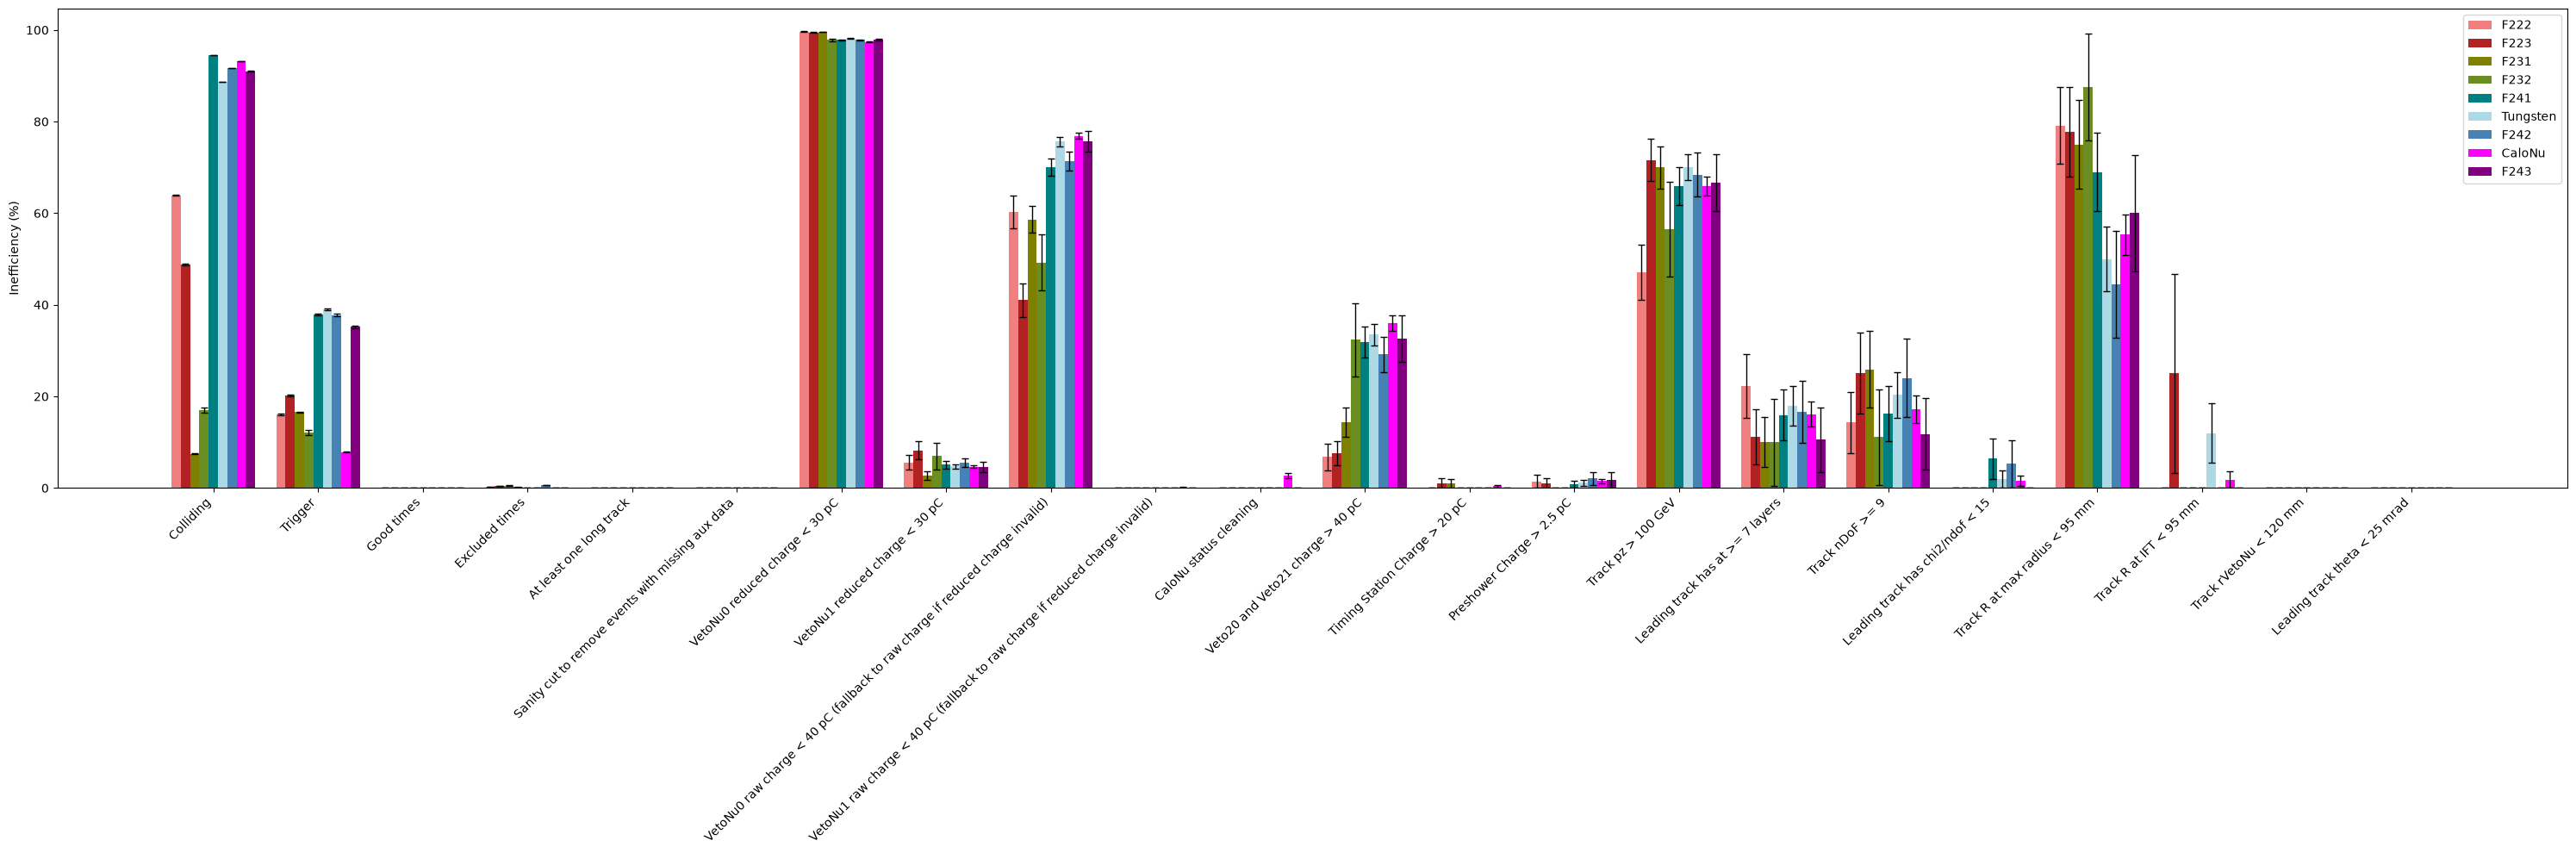

In [10]:
dfs = [cutflow_F222, cutflow_F223, cutflow_F231, cutflow_F232, cutflow_F241, cutflow_tungsten, cutflow_F242, cutflow_caloNu, cutflow_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]
colours = ["lightcoral", "firebrick", "olive", "olivedrab", "teal", "lightblue", "steelblue", "magenta", "purple"]

fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        100 - df["efficiency"]*100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        100 - df["efficiency"]*100,
        yerr=df["efficiency_error"]*100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Inefficiency (%)")

plt.tight_layout()
plt.savefig("cutflow_inefficiency_comparison.png", dpi=300)
plt.show()

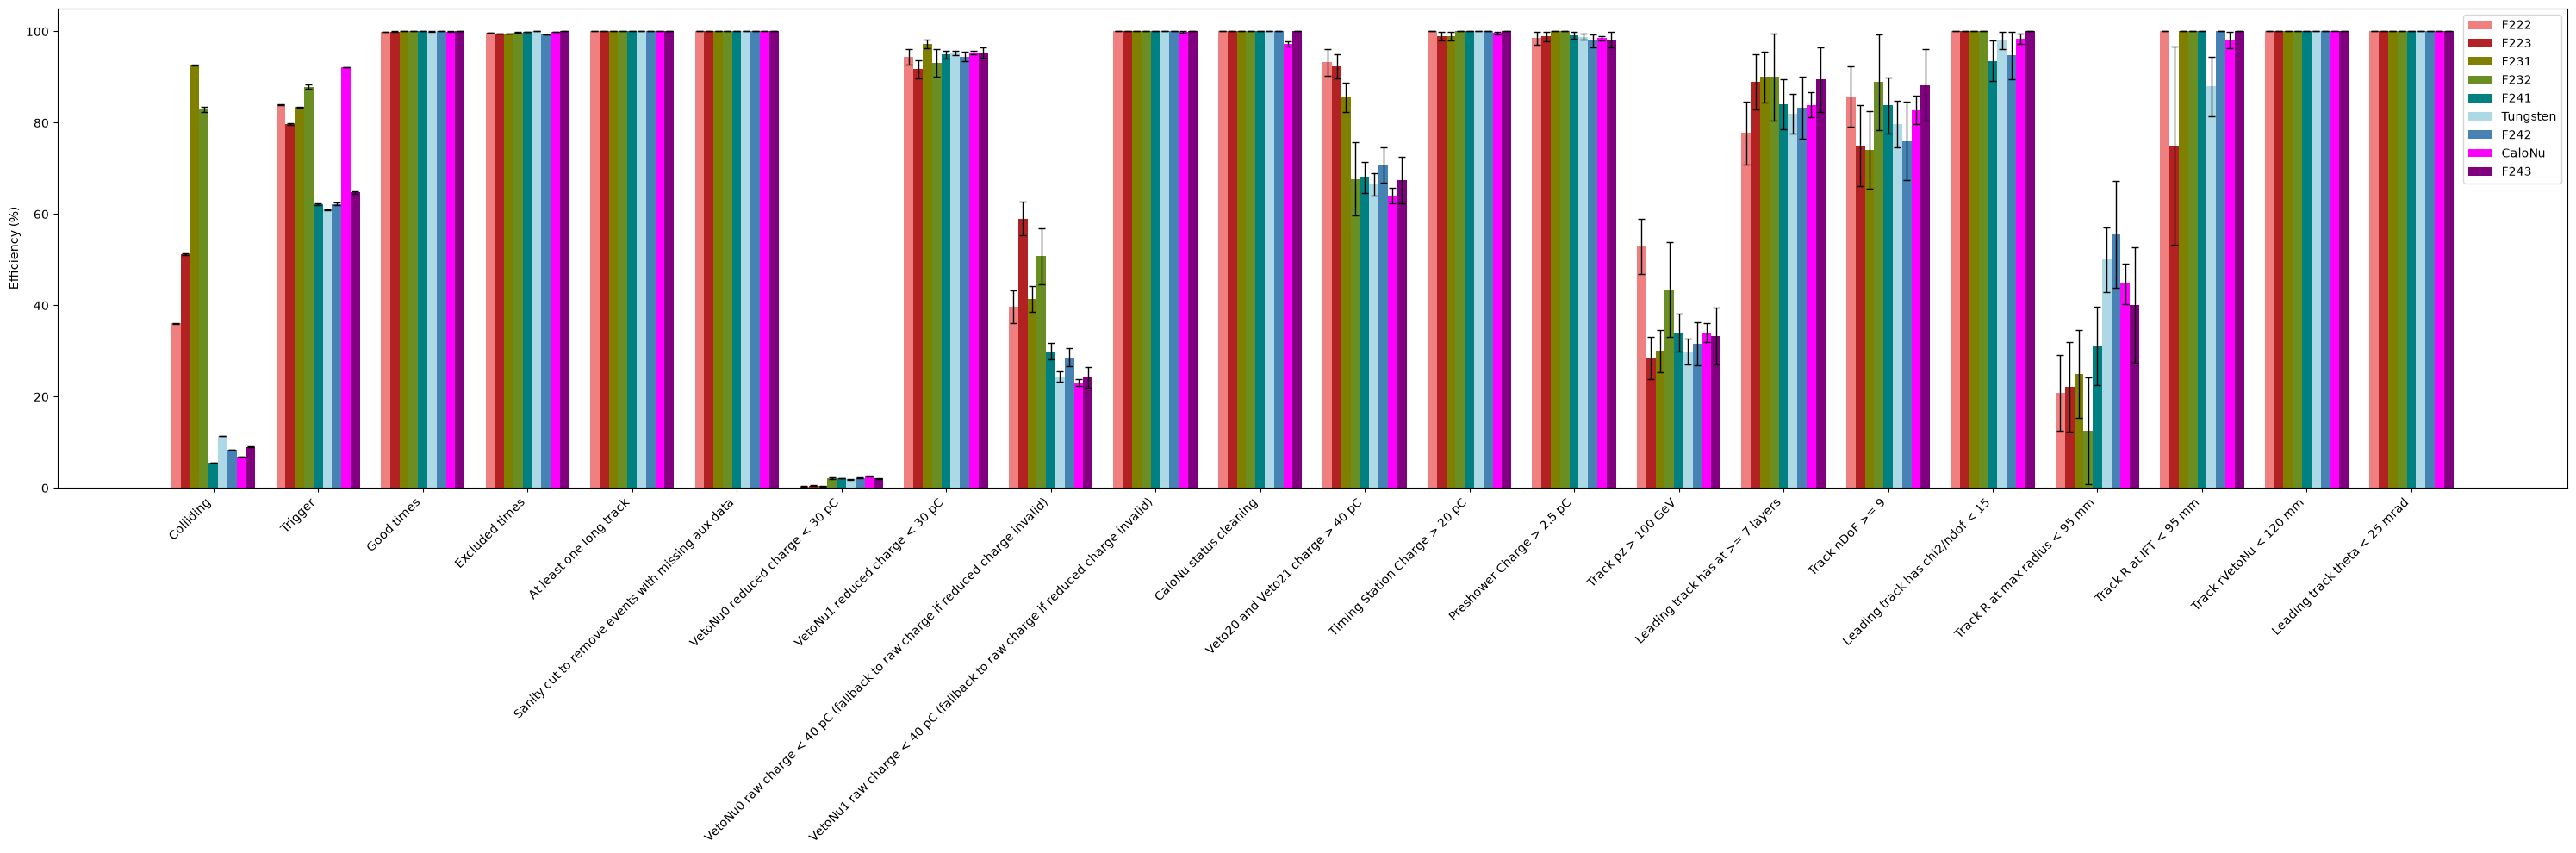

In [11]:
dfs = [cutflow_F222, cutflow_F223, cutflow_F231, cutflow_F232, cutflow_F241, cutflow_tungsten, cutflow_F242, cutflow_caloNu, cutflow_F243]
labels = ["F222", "F223", "F231", "F232", "F241", "Tungsten", "F242", "CaloNu", "F243"]
fig, ax = plt.subplots(figsize=(30, 10))

n = len(dfs)
x = np.arange(len(dfs[0]))
total_width = 0.8           # Total width occupied by all bars
bar_width = total_width / n

for i, (df, label) in enumerate(zip(dfs, labels)):
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        df["efficiency"]*100,
        width=bar_width,
        label=label,
        color=colours[i]
    )
    ax.errorbar(
        x + offset,
        df["efficiency"]*100,
        yerr=df["efficiency_error"]*100,
        fmt='none',
        ecolor='black',
        capsize=3,
        elinewidth=1,
        label=None
    )

ax.set_xticks(x)
ax.set_xticklabels(dfs[0].index, rotation=45, ha="right")
ax.legend()
ax.set_ylabel("Efficiency (%)")
# ax.set_yscale("log")

plt.tight_layout()
plt.savefig("cutflow_efficiency_comparison.png", dpi=300)
plt.show()

Trigger:
- `0x8`: [8] Second VetoLayer OR CaloNuBottom 
- `0x10`: [16] TimingLayerBottom
- `0x20`: [32] TimingLayerTop
- `0x40`: [64] PreshowerLayer

In [12]:
fpaths_late = glob.glob("AnalysisZipFramework/submission/analysis_output-lateTracks/*.root")
fpaths_late = [f"{f}:nt" for f in fpaths_late]

data_late = uproot.concatenate(fpaths_late, library="ak", filter_name=["run", "eventID", "VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "TAP", "inputBits", "inputBitsNext", "LeadTrack_r_atMaxRadius","LeadTrack_rIFT", "LeadTrack_qop", "LeadTrack_pz0", "LeadTrack_Theta"])

In [15]:
fpaths_intime = glob.glob("AnalysisZipFramework/submission/analysis_output-moreHists4/*.root")
fpaths_intime = [f"{f}:nt" for f in fpaths_intime]

data_intime = uproot.concatenate(fpaths_intime, library="ak", filter_name=["run", "eventID", "VetoNu0_reduced_charge", "VetoNu1_reduced_charge", "TAP", "inputBits", "inputBitsNext", "LeadTrack_r_atMaxRadius","LeadTrack_rIFT", "LeadTrack_qop", "LeadTrack_pz0", "LeadTrack_Theta"])

In [16]:
# data_late_good = data_late[data_late["run"].isin(good_runs)]
# data_intime_good = data_intime[data_intime["run"].isin(good_runs)]

data_late_good = data_late[np.isin(data_late["run"], good_runs)]
data_intime_good = data_intime[np.isin(data_intime["run"], good_runs)]

In [17]:
late_events = set(data_late_good["eventID"])
intime_events = set(data_intime_good["eventID"])

diff = late_events - intime_events

print(f"Number of late events: {len(late_events)}")
print(f"Number of intime events: {len(intime_events)}")
print(f"Number of events in late tracks but not in intime: {len(diff)}")

Number of late events: 115
Number of intime events: 848
Number of events in late tracks but not in intime: 115


In [18]:
bins = [-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]

h_reduced_charge0_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_reduced_charge1_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())

h_reduced_charge0_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_reduced_charge1_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())

h_reduced_charge0_late.fill(data_late_good["VetoNu0_reduced_charge"])
h_reduced_charge1_late.fill(data_late_good["VetoNu1_reduced_charge"])

h_reduced_charge0_intime.fill(data_intime_good["VetoNu0_reduced_charge"])
h_reduced_charge1_intime.fill(data_intime_good["VetoNu1_reduced_charge"])

Histogram(Variable([-1, 0, 2, 4, 6, 8, 10, 15, 20, 30]), storage=Weight()) # Sum: WeightedSum(value=848, variance=848)

<Axes: xlabel='VetoNu0 Reduced Charge [pC]', ylabel='$\\frac{In time data}{Late data}$'>

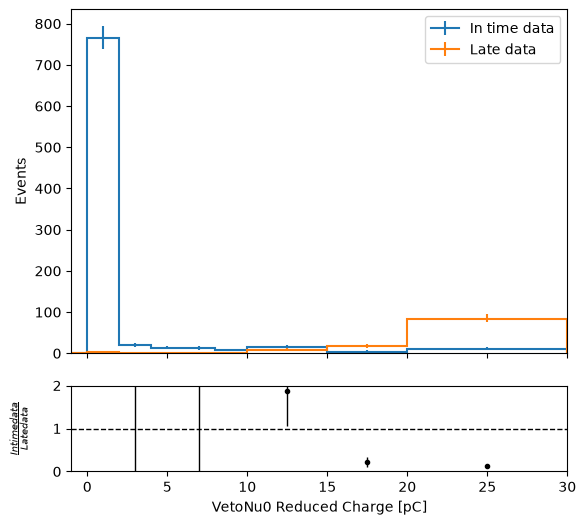

In [19]:
# Create comparison plot
fig, ax_main, ax_comp = mh.comp.hists(
 h_reduced_charge0_intime,
 h_reduced_charge0_late,
 comparison='ratio',
 xlabel='VetoNu0 Reduced Charge [pC]',
 ylabel='Events',
 h1_label='In time data',
 h2_label='Late data'
)

mh.mpl_magic(soft_fail=True) # Autofit label


<Axes: xlabel='VetoNu1 Reduced Charge [pC]', ylabel='$\\frac{In time data}{Late data}$'>

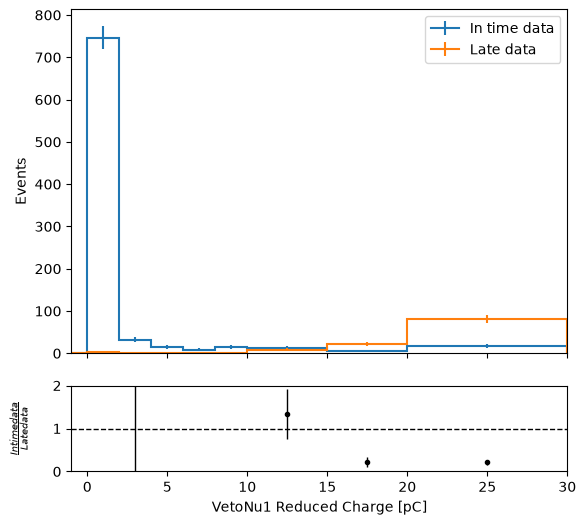

In [20]:
# Create comparison plot
fig, ax_main, ax_comp = mh.comp.hists(
 h_reduced_charge1_intime,
 h_reduced_charge1_late,
 comparison='ratio',
 xlabel='VetoNu1 Reduced Charge [pC]',
 ylabel='Events',
 h1_label='In time data',
 h2_label='Late data'
)

mh.mpl_magic(soft_fail=True) # Autofit label


In [21]:
print("Event,Run,Tap")
for event, run, tap in zip(data_late_good["eventID"], data_late_good["run"], data_late_good["TAP"]):
    print(f"{event},{run},{tap}")

Event,Run,Tap
55416350,16068,4
84463821,16023,7
27909799,15394,6
44642481,15394,6
3445129,15683,6
19427457,15785,6
40474719,15785,15
9376553,9073,6
2108078,16403,4
18762542,14771,6
72960323,15878,4
17600173,8850,6
20790093,8934,14
14762429,8266,6
10675685,15052,6
2593240,15439,6
25762823,15439,2
32875343,10794,2
50404331,15751,6
16742162,15789,2
14847782,15034,6
25212567,15034,6
2871692,16923,4
3764578,16923,4
31272779,16923,4
12795380,15884,6
11128910,15909,6
69234323,15909,4
23298048,15438,6
44462642,15438,15
13344516,15844,2
3104343,14760,14
7916957,16731,4
14368099,15415,6
85305650,15915,7
2986456,16065,4
6002651,15287,6
8572242,15790,2
14778761,16022,4
32255485,16022,6
10960746,15919,4
30448667,16396,4
44502865,15956,7
40016530,15051,6
53252655,15051,14
24652897,15422,2
26803301,15387,15
14531722,16653,2
52487702,16653,4
66962219,16653,7
20272356,16028,4
34792895,16028,4
68909799,16943,6
47931347,15055,6
37381399,16096,4
29431656,16581,4
57459506,16581,4
59319241,16581,7
20440949,

In [22]:
bins =  np.linspace(0, 16, 17)
h_tap_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_tap_late.fill(data_late_good["TAP"])

bins =  np.linspace(0, 16, 17)
h_tap_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_tap_intime.fill(data_intime["TAP"])

Histogram(Variable([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]), storage=Weight()) # Sum: WeightedSum(value=850, variance=850)

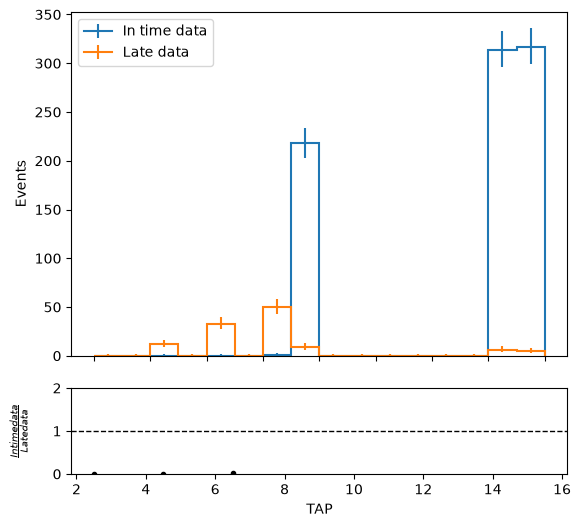

In [23]:
fig, ax_main, ax_comp = mh.comp.hists(
 h_tap_intime,
 h_tap_late,
 comparison='ratio',
 xlabel='TAP',
 ylabel='Events',
 h1_label='In time data',
 h2_label='Late data',
 flow='show'
)

In [24]:
bins =  np.linspace(0, 300, 301)
print(bins)
h_ibits_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_ibits_late.fill(data_late_good["inputBits"])

h_ibits_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_ibits_intime.fill(data_intime["inputBits"]);

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139.
 140. 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153.
 154. 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167.
 168. 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181.
 182. 183. 184. 185. 186. 187. 188. 189. 190. 191. 192. 193. 194. 195.
 196. 

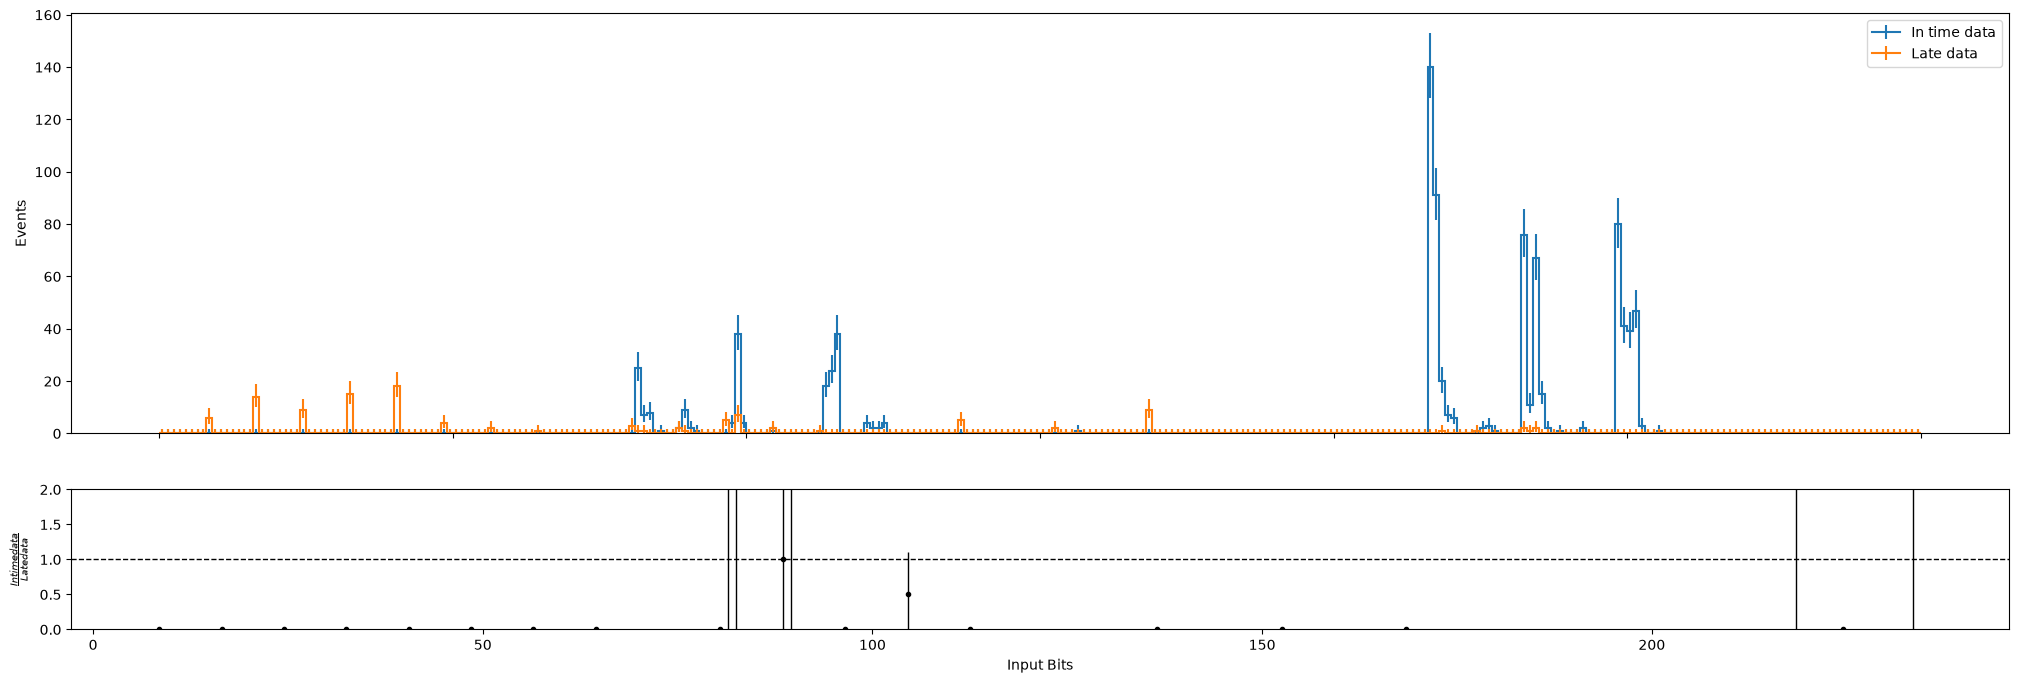

In [25]:
fig, (ax_main, ax_comp) = plt.subplots(2, 1, figsize=(25, 8), gridspec_kw={'height_ratios': [3, 1]})

fig, ax_main, ax_comp = mh.comp.hists(
    h_ibits_intime,
    h_ibits_late,
    fig=fig,
    ax_main=ax_main,
    ax_comparison=ax_comp,
    comparison='ratio',
    xlabel='Input Bits',
    ylabel='Events',
    h1_label='In time data',
    h2_label='Late data',
    flow='show',
)

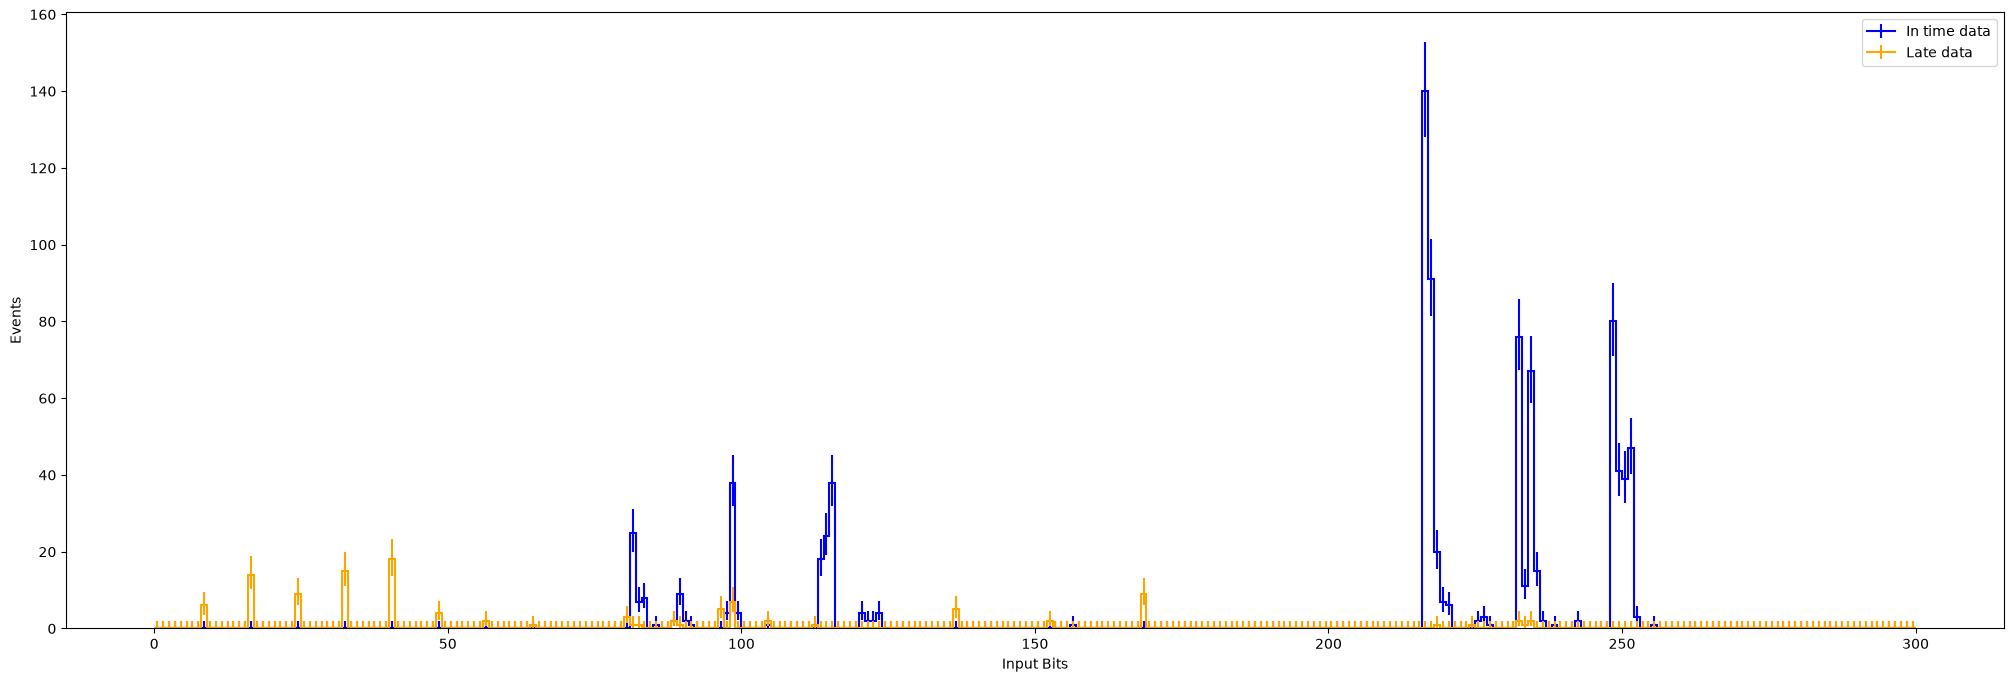

In [26]:
fig, ax = plt.subplots(figsize=(25, 8))
mh.histplot(
    h_ibits_intime,
    ax=ax,
    label='In time data',
    color='blue',
    flow='show'
)
mh.histplot(
    h_ibits_late,
    ax=ax,
    label='Late data',
    color='orange',
    flow='show'
)
ax.set_xlabel('Input Bits')
ax.set_ylabel('Events')
ax.legend()

In [27]:
bins =  np.linspace(0, 300, 301)
print(bins)
h_ibitsNext_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_ibitsNext_late.fill(data_late_good["inputBitsNext"])

h_ibitsNext_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_ibitsNext_intime.fill(data_intime["inputBitsNext"]);

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139.
 140. 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153.
 154. 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167.
 168. 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181.
 182. 183. 184. 185. 186. 187. 188. 189. 190. 191. 192. 193. 194. 195.
 196. 

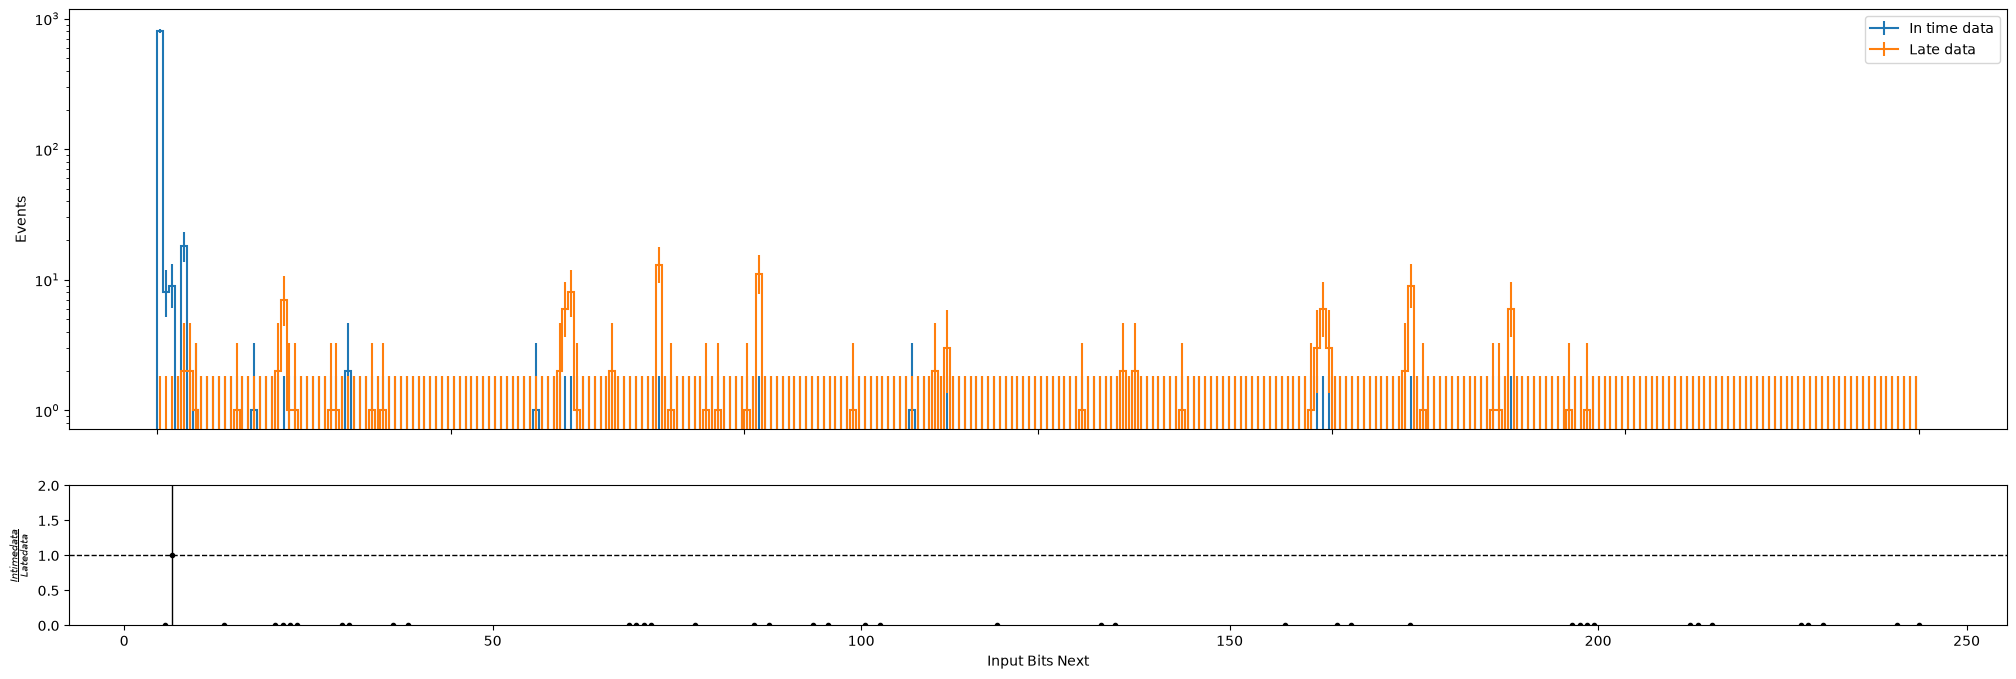

In [28]:
fig, (ax_main, ax_comp) = plt.subplots(2, 1, figsize=(25, 8), gridspec_kw={'height_ratios': [3, 1]})

fig, ax_main, ax_comp = mh.comp.hists(
    h_ibitsNext_intime,
    h_ibitsNext_late,
    fig=fig,
    ax_main=ax_main,
    ax_comparison=ax_comp,
    comparison='ratio',
    xlabel='Input Bits Next',
    ylabel='Events',
    h1_label='In time data',
    h2_label='Late data',
    flow='show',
)
ax_main.set_yscale("log")

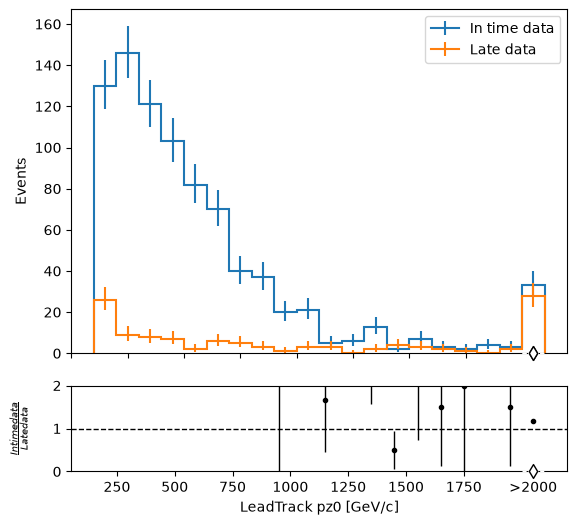

In [29]:
bins = np.linspace(100, 2000, 20)

h_pz0_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_pz0_late.fill(data_late_good["LeadTrack_pz0"])

h_pz0_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_pz0_intime.fill(data_intime_good["LeadTrack_pz0"]);

fig, ax_main, ax_comp = mh.comp.hists(
    h_pz0_intime,
    h_pz0_late,
    comparison='ratio',
    xlabel='LeadTrack pz0 [GeV/c]',
    ylabel='Events',
    h1_label='In time data',
    h2_label='Late data',
    flow='show',
)

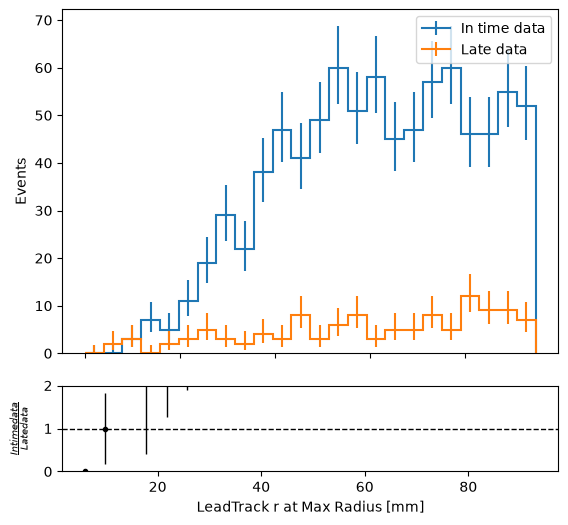

In [30]:
bins = np.linspace(0, 95, 25)

h_rMaxRad_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_rMaxRad_late.fill(data_late_good["LeadTrack_r_atMaxRadius"])

h_rMaxRad_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_rMaxRad_intime.fill(data_intime_good["LeadTrack_r_atMaxRadius"]);

fig, ax_main, ax_comp = mh.comp.hists(
    h_rMaxRad_intime,
    h_rMaxRad_late,
    comparison='ratio',
    xlabel='LeadTrack r at Max Radius [mm]',
    ylabel='Events',
    h1_label='In time data',
    h2_label='Late data',
    flow='show',
)

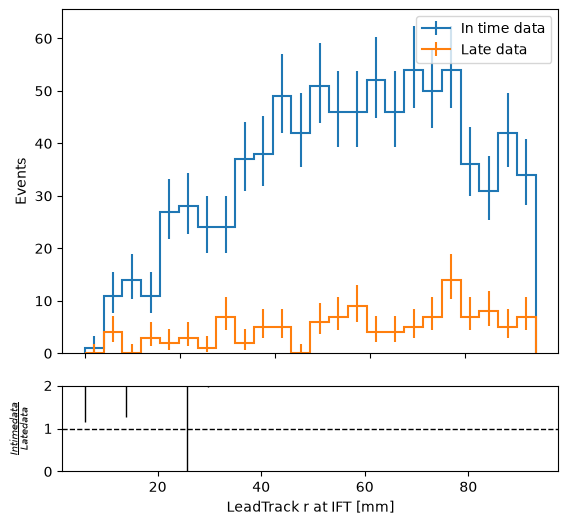

In [31]:
bins = np.linspace(0, 95, 25)

h_rIFT_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_rIFT_late.fill(data_late_good["LeadTrack_rIFT"])

h_rIFT_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_rIFT_intime.fill(data_intime_good["LeadTrack_rIFT"]);

fig, ax_main, ax_comp = mh.comp.hists(
    h_rIFT_intime,
    h_rIFT_late,
    comparison='ratio',
    xlabel='LeadTrack r at IFT [mm]',
    ylabel='Events',
    h1_label='In time data',
    h2_label='Late data',
    flow='show',
)

24.99116376227716
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25.]


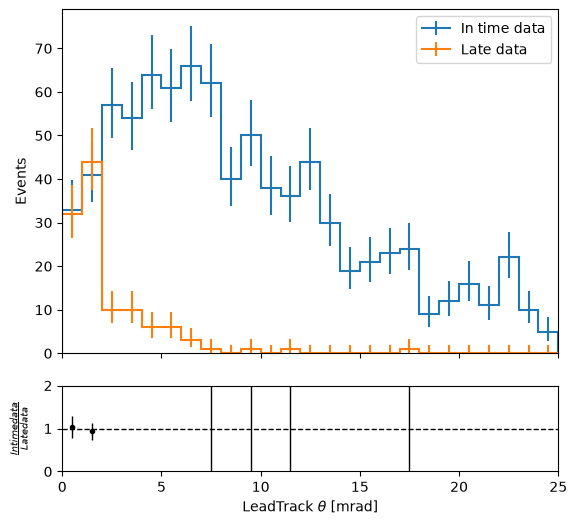

In [32]:
bins = np.linspace(0, 25, 26)

h_theta_late = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_theta_late.fill(data_late_good["LeadTrack_Theta"])

h_theta_intime = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())
h_theta_intime.fill(data_intime_good["LeadTrack_Theta"]);

print(max(data_intime_good["LeadTrack_Theta"]))
print(bins)

fig, ax_main, ax_comp = mh.comp.hists(
    h_theta_intime,
    h_theta_late,
    comparison='ratio',
    xlabel=r'LeadTrack $\theta$ [mrad]',
    ylabel='Events',
    h1_label='In time data',
    h2_label='Late data',
    # flow='show',
)